In [7]:
import torch.utils.data as data
from torch_geometric.loader import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
import numpy as np
import torch_geometric

from torch_geometric.data import Data
import torch
import numpy as np

import torch.nn as nn
from torch.nn import Linear, Parameter
from torch_geometric.nn import MessagePassing, global_add_pool
from torch_geometric.utils import add_self_loops, degree, scatter, index_to_mask
import torch.nn.functional as F

from torchvision import transforms
import matplotlib.pyplot as plt

#Device Agnostic code
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

In [10]:
#merging all datasets in random fashion so to get 1000 samples from each mass
dataset = []

def Jet_Dataset(file):

    jet_data = np.loadtxt(file)
    
    # columns: jet_id, E, px, py, pz, eta, phi, pt, tau43, tau32, tau21, multiplicity, mt, 

    graphs = []
    jet_ids = np.unique(jet_data[:, 0].astype(int))
    
    for jet_id in jet_ids:
        mask = jet_data[:, 0] == jet_id
        data = jet_data[mask]

        #node features:
        x = torch.tensor(data[:, 1:8], dtype=torch.float32)  # E, px, py, pz, eta, phi, pt 
        x = torch.nan_to_num(x, nan=0.0)
        n = x.shape[0] #number of nodes
        
        #for creating edges, let us do it the way of zetaij,
        source = []
        target = []
        
        edge_zeta = []
        deltaR = []

        for i in range(n):
            for j in range(n):
                if i != j:
                    source.append(i) 
                    target.append(j)
                    
                    pi,etai,phii = data[i,2:5],data[i,5],data[i,6]
                    pj,etaj,phij = data[j,2:5],data[j,5],data[j,6] 
                    magi = np.linalg.norm(pi) #dot pdt and sqrt
                    magj = np.linalg.norm(pj) #same
                    
                    if magi == 0 or magj == 0:
                        zeta = 0.0
                    else:
                        cos_theta = np.clip(np.dot(pi, pj) / (magi * magj), -1, 1)
                        zeta = (1 - cos_theta) / 2
                    
                    #wrapping it up
                    dphi = phii - phij
                    dphi = (dphi + np.pi) % (2*np.pi) - np.pi
                    deta = etai -etaj
                    part_del_R = np.hypot(deta,dphi)

                    #edge attributes
                    edge_zeta.append(zeta)
                    deltaR.append(part_del_R)

        edge_index = torch.tensor([source, target], dtype = torch.long)
        edge_attr = torch.stack([torch.tensor(edge_zeta,dtype=torch.float32), torch.tensor(deltaR, dtype=torch.float32)], dim=1)

        #label: mt
        mt = float(data[0,-1])
        
        y = torch.tensor(mt, dtype=torch.float32)
        
        graphs.append(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y))

    return graphs



In [11]:
all_graphs = []

for mt in np.arange(170.0, 180.5, 0.5):
    file = f"/home/sawini-jana/hep/PaperGNN/datasetforGNN_{mt:.1f}.txt"

    graphs = Jet_Dataset(file)

    all_graphs.extend(graphs)

#all_graphs itself is now the dataset

In [12]:
raw_pt = []
raw_E = []
masses = []

for g in all_graphs:
    raw_pt.append(g.x[:,6].sum().item())
    raw_E.append(g.x[:,0].sum().item())
    masses.append(g.y.item())

print("pt corr =", np.corrcoef(raw_pt, masses)[0,1])
print("E corr  =", np.corrcoef(raw_E, masses)[0,1])

pt corr = 0.0024353761697351937
E corr  = -0.0008401254326442487


In [13]:

from tqdm import tqdm
from tqdm import trange

#Creating training and testing datasets
batch_size = 32
test_size = 0.10
num_samples = len(all_graphs)

test_no = int(test_size * num_samples)
valid_no = test_no

train_no = len(all_graphs) - test_no*2

np.random.seed(42)
indices = np.arange(len(all_graphs))
np.random.shuffle(indices)
train_index, test_index, valid_index = indices[:train_no], indices[train_no:train_no+test_no], indices[train_no+test_no:train_no+test_no+valid_no]

# define samplers for obtaining training and testing batches
train_sampler = SubsetRandomSampler(train_index)
test_sampler = SubsetRandomSampler(test_index)
valid_sampler = SubsetRandomSampler(valid_index)

train_load = DataLoader(all_graphs, batch_size = batch_size, sampler = train_sampler)
test_load = DataLoader(all_graphs, batch_size = batch_size, sampler = test_sampler)
valid_load = DataLoader(all_graphs, batch_size = batch_size, sampler = valid_sampler)

In [14]:
all_masses = []
for data in train_load:
    all_masses.append(data.y)
    
all_masses = torch.cat(all_masses, dim=0)
m_mean = all_masses.mean().item()
m_std = all_masses.std().item()

In [15]:
all_x = torch.cat([all_graphs[i].x for i in train_index], dim=0)
x_mean = all_x.mean(dim=0)
x_std  = all_x.std(dim=0)
x_std[x_std < 1e-3] = 1.0

for g in all_graphs:
    g.x = (g.x - x_mean) / x_std

In [16]:

class CustomGCNConv(MessagePassing):

    def __init__(self, in_channels, out_channels):
        super().__init__(aggr="add")
        self.lin = Linear(in_channels, out_channels, bias =False)
        self.bias = Parameter(torch.empty(out_channels))

        self.reset_parameters()
    
    def reset_parameters(self):
        self.lin.reset_parameters()
        self.bias.data.zero_()

    def forward(self, x, edge_index, batch):
        #x --> [N, in_channels]
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0)) #2,E
        
        x = self.lin(x) # x --> [N, out_channels]

        source, target = edge_index #[E]
        #print(f"HI: {len(target)}")
        deg = degree(target, x.size(0), dtype=x.dtype) #[N]
        deg_inv_sqrt = deg.pow(-0.5) #[N]
        deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
        norm = deg_inv_sqrt[source] * deg_inv_sqrt[target] #[E]
        #print(f"HI: {norm.shape}")
        out = self.propagate(edge_index, x=x, norm=norm)
        #[N, out_channels]
        #but why change from E to N? 

        out = out + self.bias
        
        return out

    def message(self, x_j, norm):
        return norm.view(-1, 1) * x_j
           #*[E,1] x [E, out_channels] = [E, out_channels] 
class GCNModule(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = CustomGCNConv(in_dim, hidden_dim)
        self.conv2 = CustomGCNConv(hidden_dim, hidden_dim)
        self.conv3 = CustomGCNConv(hidden_dim, hidden_dim)
        self.lin1 = nn.Linear(hidden_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, out_dim)

        # Force variance-preserving initialization
        nn.init.xavier_uniform_(self.lin1.weight)
        nn.init.xavier_uniform_(self.lin2.weight)

    def forward(self, x, edge_index, batch):
        h = F.leaky_relu(self.conv1(x, edge_index, batch), 0.2)
        h = h + F.leaky_relu(self.conv2(h, edge_index, batch), 0.2)
        h = h + F.leaky_relu(self.conv3(h, edge_index, batch), 0.2)
        x = h
        x = global_add_pool(x, batch)
        x = F.leaky_relu(self.lin1(x), 0.2)
        return self.lin2(x)

model = GCNModule(in_dim=7, hidden_dim=64, out_dim=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)
loss = nn.MSELoss()

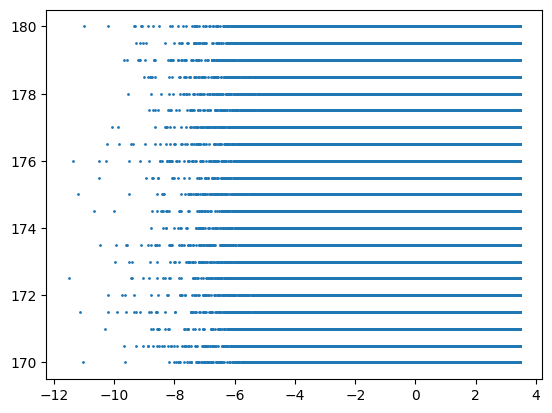

In [17]:
pts = []
masses = []

for g in all_graphs:
    pts.append(g.x[:,6].sum().item())
    masses.append(g.y.item())

plt.scatter(pts, masses, s=1)
plt.show()

In [18]:
for data in train_load:
    out = model(data.x, data.edge_index, data.batch)
    print("any nan in output:", torch.isnan(out).any().item())
    break

any nan in output: False


In [19]:

#training model
def train(train_loader, model, optimizer, loss_fn):
    model.train()
    train_loss = 0

    for data in tqdm(train_loader, desc="Training batches"):
        data = data.to(device)
        #print(f"MYDATA: {data}")
        y_pred = model(data.x, data.edge_index, data.batch)
        #print("train pred: ", y_pred)
        y_norm = (data.y - m_mean) / m_std
        loss = loss_fn(y_pred.squeeze(), y_norm)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        

    train_loss /= len(train_loader)
    return train_loss


def test(test_loader, model, loss_fn):
    model.eval()
    test_loss = 0

    with torch.inference_mode():
        for data in test_loader:

            data = data.to(device)

            test_pred = model(data.x, data.edge_index, data.batch)
            y_norm = (data.y - m_mean) / m_std
            #print("TEST_PRED:",test_pred)
            loss = loss_fn(test_pred.squeeze(), y_norm)
            #print("Data_label:", data.label )
            test_loss += loss.item()

    test_loss /= len(test_loader)

    return test_loss


Processing:   7%|▋         | 1/15 [01:07<15:40, 67.21s/it]

Epoch 0 | Train Loss: 1.023686743304843 | Test Loss: 1.0104294056398866


Processing:  13%|█▎        | 2/15 [02:08<13:48, 63.75s/it]

Epoch 1 | Train Loss: 1.0022422402586255 | Test Loss: 1.0000765013368162


Processing:  20%|██        | 3/15 [03:15<13:04, 65.40s/it]

...

Epoch 12 | Train Loss: 1.0001672406083062 | Test Loss: 0.9991437919789434


Processing:  93%|█████████▎| 14/15 [14:55<01:04, 64.99s/it]

Epoch 13 | Train Loss: 1.0001864657799402 | Test Loss: 0.9989335251181093


Processing: 100%|██████████| 15/15 [16:02<00:00, 64.18s/it]

Epoch 14 | Train Loss: 1.0000861664556322 | Test Loss: 0.999861890821515
Best for test Loss: 0.998465631015406


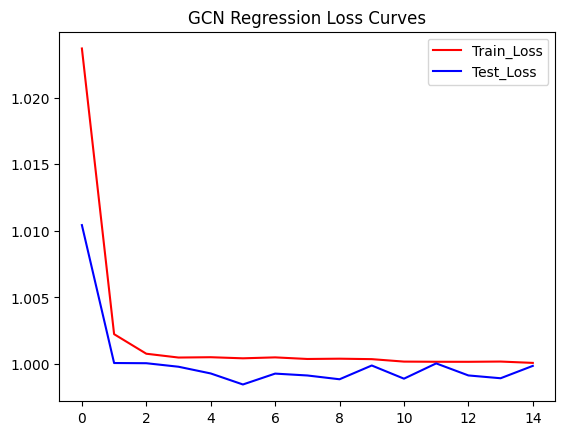

In [20]:

ep = []
result1 = []
result2 = []
min = torch.inf

import numpy as np
for epoch in trange (15, desc="Processing"):
    train_loss = train(train_load, model, optimizer, loss)
    test_loss = test( test_load,model, loss)
    ep.append(epoch)
    result1.append(np.array(torch.tensor(train_loss).numpy()))
    result2.append(np.array(torch.tensor(test_loss).numpy()))

    #draw_epoch_graph(G, model_1.latest)
    print(f"Epoch {epoch} | Train Loss: {train_loss} | Test Loss: {test_loss}")

    if test_loss < min:
        min = test_loss
        torch.save(model.state_dict(), 'model.pt')
    
    scheduler.step(test_loss)
    
print(f"Best for test Loss: {min}")
#plotting loss curves
plt.plot(ep, result1, color = "red", label = "Train_Loss")
plt.plot(ep, result2, color = "blue", label="Test_Loss")
plt.legend()
plt.title("GCN Regression Loss Curves")
plt.show()


Best for test Loss: 0.998465631015406


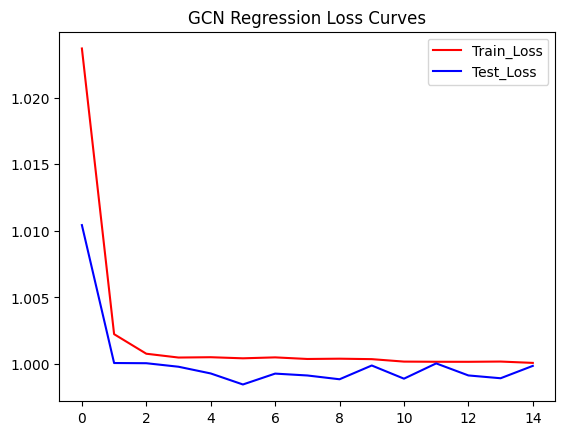

In [21]:
print(f"Best for test Loss: {min}")
#plotting loss curves
plt.plot(ep, result1, color = "red", label = "Train_Loss")
plt.plot(ep, result2, color = "blue", label="Test_Loss")
plt.legend()
plt.title("GCN Regression Loss Curves")
plt.show()

In [22]:
all_graphs[0].y.dtype

torch.float32

In [23]:

model_test = GCNModule(in_dim= len(all_graphs[0].x[0]),hidden_dim = 64, out_dim = 1)
model_test.load_state_dict(torch.load('model.pt', weights_only=True))
model_test.to(device)

model.eval()
preds=[]
truths = []

with torch.no_grad():
    for data in valid_load:
        data = data.to(device)

        pred = model_test(data.x,data.edge_index,data.batch).squeeze()
        pred_denorm = pred * m_std + m_mean
        preds.append(pred_denorm)
        truths.append(data.y)

preds = torch.cat(preds)
truths = torch.cat(truths)
rmse = torch.sqrt(torch.mean((preds - truths)**2))
mae = torch.mean(torch.abs(preds - truths))

print("RMSE =", rmse.item())
print("MAE  =", mae.item())

import random
idx = random.randint(0, len(all_graphs))
valid = all_graphs[idx]
data = valid.to(device)

valid_pred = model_test(data.x, data.edge_index, data.batch)
valid_pred_denorm = valid_pred * m_std + m_mean
print("PREDICTED MASS: ", valid_pred_denorm)
print("TRUTH MASS: ", data.y)


RMSE = 3.028080463409424
MAE  = 2.6203055381774902
PREDICTED MASS:  tensor([[174.9825]], grad_fn=<AddBackward0>)
TRUTH MASS:  tensor(173.5000)


In [24]:

class MPNNLayer(MessagePassing):
    def __init__(self, emb_dim , hidden_layers , edge_dim, aggr='add'):   #(64, 32, 1)
        super().__init__(aggr=aggr)

        self.emb_dim = emb_dim      #64
        self.edge_dim = edge_dim    #2
        
        self.mlp_msg = nn.Sequential(
            Linear(2 * emb_dim + edge_dim, hidden_layers), nn.BatchNorm1d(hidden_layers), nn.ReLU(),nn.Dropout(0.5),
            Linear(hidden_layers, emb_dim), nn.ReLU(),nn.Dropout(0.5), nn.BatchNorm1d(emb_dim)
        )    #(E, 64)

        self.upd_msg = nn.Sequential(
            Linear(emb_dim * 2, hidden_layers), nn.BatchNorm1d(hidden_layers), nn.ReLU(),
            Linear(hidden_layers, emb_dim), nn.ReLU(), nn.BatchNorm1d(emb_dim)
        )   #(N, 64)

    def forward(self, x, edge_index, edge_attr):
        self.x = x  #[N,25]
        return self.propagate(edge_index=edge_index, x=x, edge_attr=edge_attr,size=(x.size(0), x.size(0)))

        #x_i contains the features of the target nodes for each edge
        #x_j contains the features of the source nodes for each edge
    def message(self, x_i, x_j, edge_attr):
        msg_input = torch.cat([x_i, x_j, edge_attr], dim=1)     #(E, 4)
        return self.mlp_msg(msg_input)                          #(E, 64)

        #inputs = the output of message
        #index is x_i
    def aggregate(self, inputs, index, ptr=None, dim_size=None):
        return scatter(inputs, index, dim=0,dim_size=dim_size, reduce=self.aggr)  #(N, 64)

        #aggr_out is the output of aggregate (N,64)
        #x is original node features (N, 64)
    def update(self, aggr_out, x):
        upd_input = torch.cat([x, aggr_out], dim=1)
        #print(upd_input.shape)
        return self.upd_msg(upd_input) #(N, 64)

class MPNNModel(nn.Module):
    def __init__(self, in_dim, edge_dim, hidden_dim=64, num_layers=3): #(25,1)
        super().__init__()

        #1.
        self.lin_in = nn.Linear(in_dim, hidden_dim)
                                  #x --> (N, 64) 
        #2. layers of calling
        self.convs = nn.ModuleList()
        for layer in range(num_layers):
            self.convs.append(MPNNLayer(emb_dim = hidden_dim ,hidden_layers =32, edge_dim = edge_dim))
                                        # emb_dim = 64                              edge_dim = 1                 
          
        #3.Pooling
        self.pool = global_add_pool #[1,64]

        
        #4. Linear
        self.lin_layer = nn.Sequential(
                                nn.Linear(hidden_dim, 1),
                                nn.ReLU())

    
    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x =self.lin_in(x) #(N, 64)
        #print("BEFORE CONV: ", x.shape)
        for conv in self.convs:
    
            x += conv(x, edge_index, edge_attr)   


        #print("AFTER CONV: ",x.shape)
        x = self.pool(x, batch) 
        #print("AFTER POOL", x.shape)
        return self.lin_layer(x).view(-1)

model = MPNNModel(in_dim= len(all_graphs[0].x[0]), edge_dim=len(all_graphs[0].edge_index) ).to(device)
#(25,1)

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3, weight_decay=5e-4)
loss = nn.MSELoss()


In [25]:
len(all_graphs[0].edge_index)

2

In [26]:
#training model
def train(train_loader, model, optimizer, loss_fn):
    model.train()
    train_loss = 0 

    for data in tqdm(train_loader, desc="Training batches"):
        data = data.to(device)
        #print(f"MYDATA: {data}")
        y_pred = model(data)
        #print(y_pred.shape, data.y.dtype)
        y_norm = (data.y - m_mean)/m_std
        loss = loss_fn(y_pred.squeeze(), y_norm)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    train_loss /= len(train_loader)
    return train_loss

def test(test_loader, model, loss_fn):
    model.eval()
    test_loss = 0

    with torch.inference_mode():
        for data in test_loader:

            data = data.to(device)

            test_pred = model(data)
            
            #print("TEST_PRED:",test_pred)
            y_norm = (data.y - m_mean)/m_std
            loss = loss_fn(test_pred.squeeze(), y_norm)
            #print("Data_label:", data.label )
            test_loss += loss.item()
            
    test_loss /= len(test_loader)

    return test_loss


In [27]:
for data in train_load:
    data = data.to(device)
    print(f"MYDATA: {data}")
    break

MYDATA: DataBatch(x=[136, 7], edge_index=[2, 782], edge_attr=[782, 2], y=[32], batch=[136], ptr=[33])


In [29]:

ep = []
result1 = []
result2 = []
min = torch.inf

import numpy as np
for epoch in trange (15, desc="Processing"):
    train_loss = train(train_load, model, optimizer, loss)
    test_loss = test( test_load,model, loss)
    ep.append(epoch)
    result1.append(np.array(torch.tensor(train_loss).numpy()))
    result2.append(np.array(torch.tensor(test_loss).numpy()))

    #draw_epoch_graph(G, model_1.latest)
    print(f"Epoch {epoch} | Train Loss: {train_loss} | Test Loss: {test_loss}")

    if test_loss < min:
        min = test_loss
        torch.save(model.state_dict(), 'model.pt')

print(f"Best for test Loss: {min}")
#plotting loss curves
plt.plot(ep, result1, color = "red", label = "Train_Loss")
plt.plot(ep, result2, color = "blue", label="Test_Loss")
plt.legend()
plt.title("MPNN_Regression Loss Curves")
plt.show()

Processing:   7%|▋         | 1/15 [03:26<48:11, 206.56s/it]

Epoch 0 | Train Loss: 1.0000446009976522 | Test Loss: 1.2913752218631849


Processing:  13%|█▎        | 2/15 [06:53<44:45, 206.61s/it]

Epoch 1 | Train Loss: 1.0000122266610463 | Test Loss: 0.9992588649601697


Processing:  20%|██        | 3/15 [17:50<1:22:31, 412.60s/it]

Epoch 2 | Train Loss: 0.9999940829617636 | Test Loss: 0.9992129342741074


Processing:  20%|██        | 3/15 [24:27<1:37:51, 489.30s/it]


KeyboardInterrupt: 

Best for test Loss: 0.9992129342741074


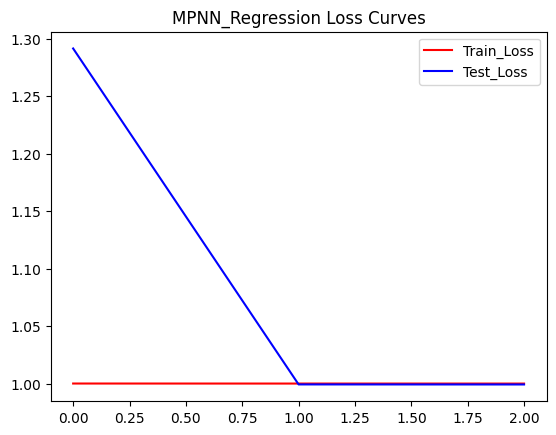

In [30]:
print(f"Best for test Loss: {min}")
#plotting loss curves
plt.plot(ep, result1, color = "red", label = "Train_Loss")
plt.plot(ep, result2, color = "blue", label="Test_Loss")
plt.legend()
plt.title("MPNN_Regression Loss Curves")
plt.show()

In [31]:


model_test = MPNNModel(in_dim= len(all_graphs[0].x[0]), edge_dim=len(all_graphs[0].edge_index))
model_test.load_state_dict(torch.load('model.pt', weights_only=True))
model_test.to(device)
model_test.eval()
preds=[]
truths = []

with torch.no_grad():
    for data in valid_load:
        data = data.to(device)

        pred = model_test(data).squeeze()
        pred_denorm = (pred - m_mean)/m_std
        preds.append(pred_denorm)
        truths.append(data.y)

preds = torch.cat(preds)
truths = torch.cat(truths)
rmse = torch.sqrt(torch.mean((preds - truths)**2))
mae = torch.mean(torch.abs(preds - truths))

print("RMSE =", rmse.item())
print("MAE  =", mae.item())

#VALIDATING
import random
idx = random.randint(0, len(all_graphs))
valid = all_graphs[idx]
data = valid.to(device)
valid_pred = model_test(data)
valid_pred_denorm = (valid_pred - m_mean)/m_std
print("PREDICTED MASS: ", valid_pred_denorm)
print("TRUTH MASS: ", data.y)

RMSE = 232.79808044433594
MAE  = 232.77838134765625
PREDICTED MASS:  tensor([-57.8003], grad_fn=<DivBackward0>)
TRUTH MASS:  tensor(174.5000)
